## Question 1: Regression Analysis & Data Preprocessing – Business and Housing Use Cases

### Scenario

You are working as a data analyst for a **real estate team** that wants to predict house prices using multiple factors.

You must clean, preprocess, analyze, and model the data appropriately.

### Datasets

* **House Prices Dataset (Multiple Linear Regression – Kaggle)**
  [https://www.kaggle.com/datasets/camnugent/california-housing-prices](https://www.kaggle.com/datasets/camnugent/california-housing-prices)

### Tasks

1. Perform **EDA** on datasets.
2. Apply required **data preprocessing** steps:

   * Handling missing values
   * Feature encoding (if applicable)
   * Feature scaling
4. Build a **Multiple Linear Regression** model for the housing dataset.
5. Interpret regression coefficients in real-world terms.
6. Evaluate model using **R²**, **MSE**, and residual analysis.
7. State and verify assumptions of linear regression.

### Step 1: Import libraries and load the dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

sns.set_style("whitegrid")

df = pd.read_csv("housing.csv")
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


### Step 2: Exploratory Data Analysis (EDA)

First I want to understand the size of the data, the data types, and whether there are missing values or duplicates.

In [2]:
print("Shape:", df.shape)
df.info()

Shape: (20640, 10)
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
longitude,20640.0,-119.569704,2.003532,-124.3500,-121.8000,-118.4900,-118.01000,-114.3100
latitude,20640.0,35.631861,2.135952,32.5400,33.9300,34.2600,37.71000,41.9500
housing_median_age,20640.0,28.639486,12.585558,1.0000,18.0000,29.0000,37.00000,52.0000
total_rooms,20640.0,2635.763081,2181.615252,2.0000,1447.7500,2127.0000,3148.00000,39320.0000
total_bedrooms,20433.0,537.870553,421.385070,1.0000,296.0000,435.0000,647.00000,6445.0000
population,20640.0,1425.476744,1132.462122,3.0000,787.0000,1166.0000,1725.00000,35682.0000
households,20640.0,499.539680,382.329753,1.0000,280.0000,409.0000,605.00000,6082.0000
median_income,20640.0,3.870671,1.899822,0.4999,2.5634,3.5348,4.74325,15.0001
median_house_value,20640.0,206855.816909,115395.615874,14999.0000,119600.0000,179700.0000,264725.00000,500001.0000


In [4]:
# missing values, duplicates and the categorical column
missing = df.isnull().sum()
print(pd.DataFrame({"missing": missing, "percent": (missing / len(df) * 100).round(2)}))
print("\nDuplicate rows:", df.duplicated().sum())
print("\n", df["ocean_proximity"].value_counts())

                    missing  percent
longitude                 0      0.0
latitude                  0      0.0
housing_median_age        0      0.0
total_rooms               0      0.0
total_bedrooms          207      1.0
population                0      0.0
households                0      0.0
median_income             0      0.0
median_house_value        0      0.0
ocean_proximity           0      0.0

Duplicate rows: 0

 ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64


Now the distribution of every numeric column. Histograms help to spot skewness, outliers and any artificial limit in the data.

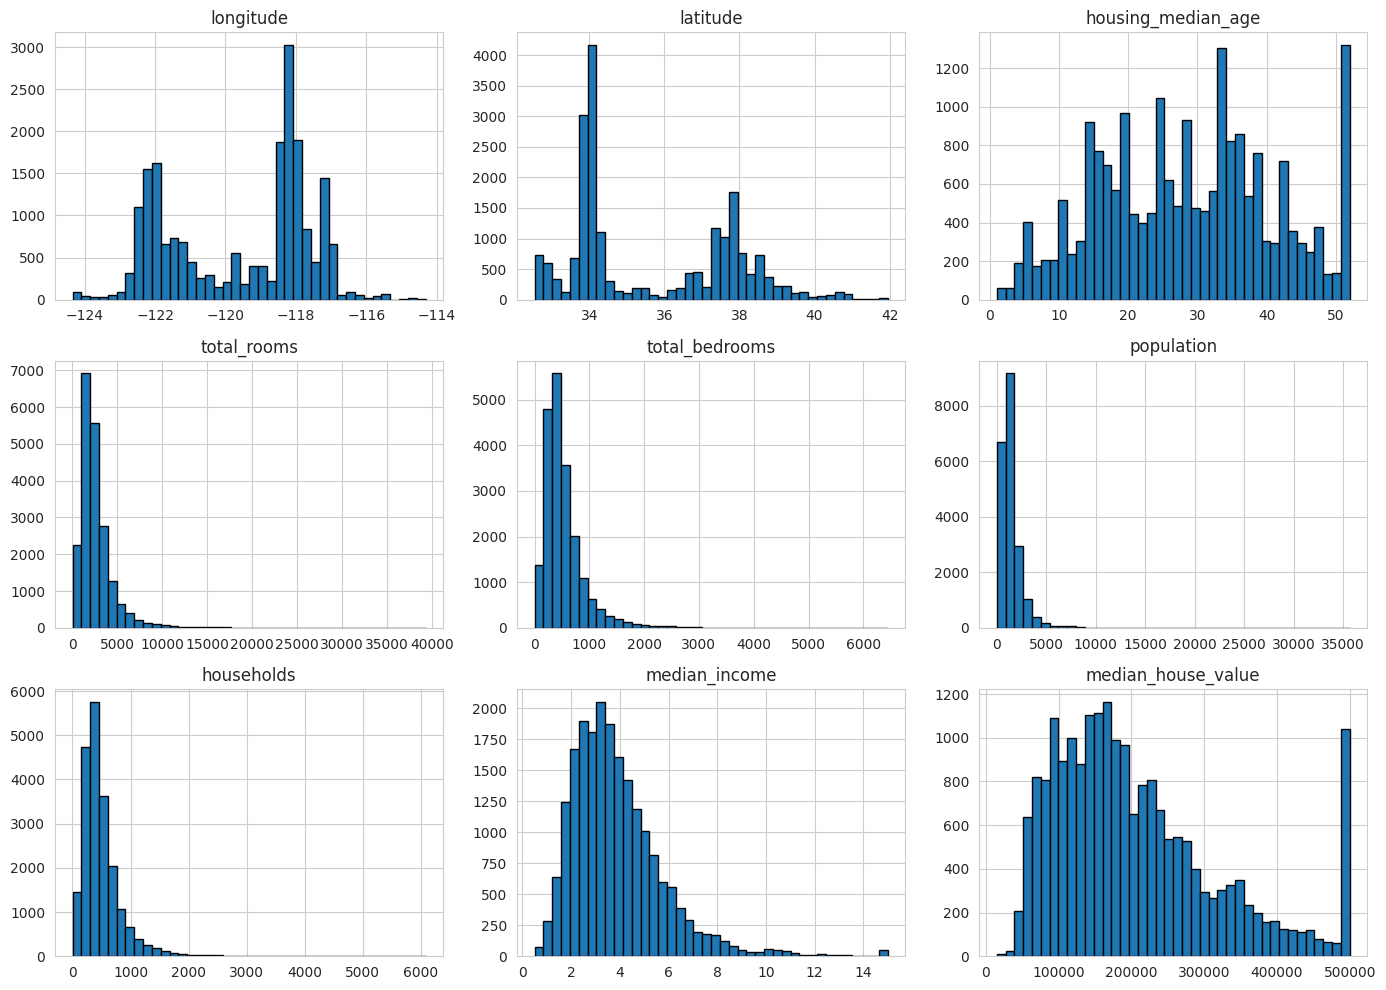

In [5]:
df.hist(bins=40, figsize=(14, 10), edgecolor="black")
plt.tight_layout()
plt.show()

Next, how the features are related to the house price. The heatmap gives the correlations, and the plots show the main patterns.

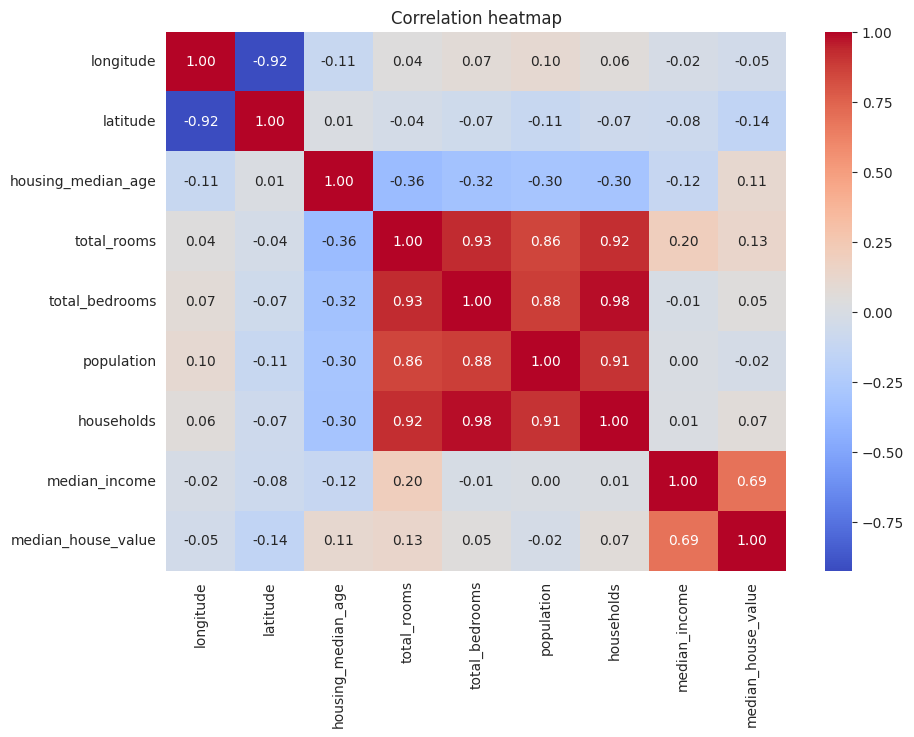

median_house_value    1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64

In [6]:
numeric = df.select_dtypes(include="number")

plt.figure(figsize=(10, 7))
sns.heatmap(numeric.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation heatmap")
plt.show()

numeric.corr()["median_house_value"].sort_values(ascending=False)

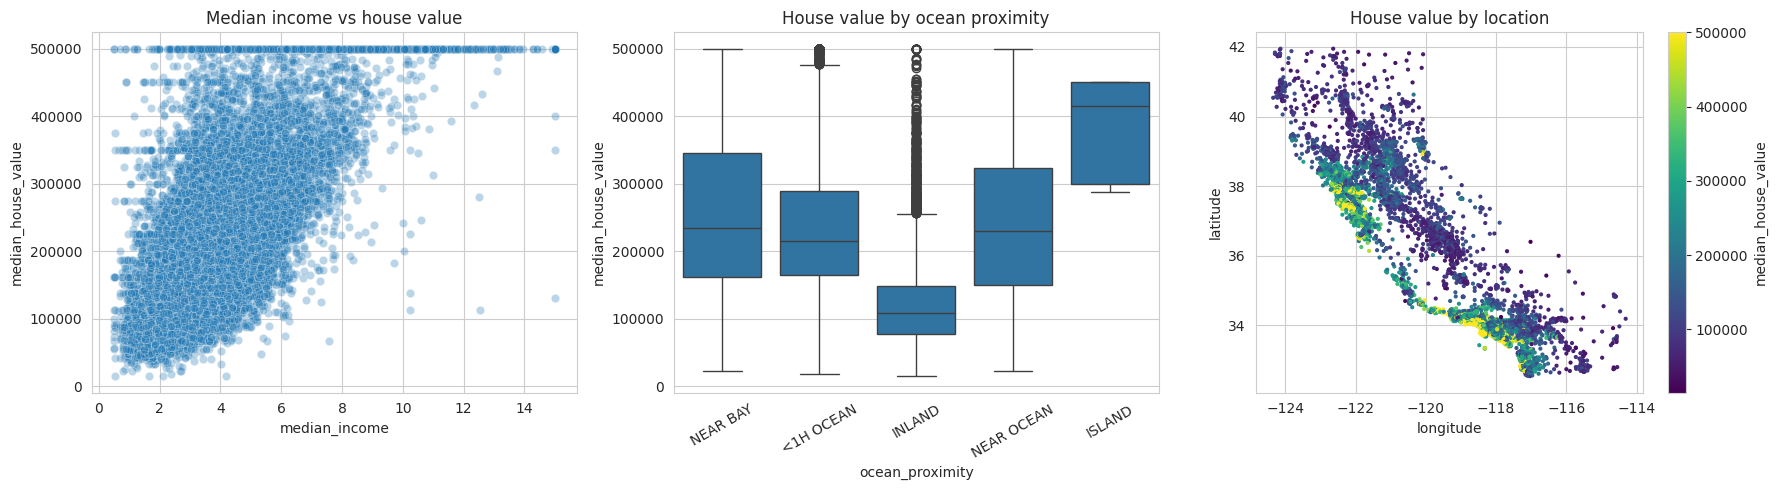

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(
    data=df, 
    x="median_income", 
    y="median_house_value", 
    alpha=0.3, 
    ax=axes[0]
)
axes[0].set_title("Median income vs house value")

sns.boxplot(
    data=df, 
    x="ocean_proximity", 
    y="median_house_value", 
    ax=axes[1]
)
axes[1].tick_params(axis="x", rotation=30)
axes[1].set_title("House value by ocean proximity")

sc = axes[2].scatter(
    df["longitude"], 
    df["latitude"], 
    c=df["median_house_value"], 
    cmap="viridis", s=4
)
plt.colorbar(
    sc, 
    ax=axes[2], 
    label="median_house_value"
)
axes[2].set_xlabel("longitude")
axes[2].set_ylabel("latitude")
axes[2].set_title("House value by location")

plt.tight_layout()
plt.show()

**EDA observations**

* The dataset has 20,640 rows and 10 columns. Only `total_bedrooms` has missing values (207 rows, about 1%), and there are no duplicate rows.
* `ocean_proximity` is the only categorical column. Most districts are `<1H OCEAN` (9,136) or `INLAND` (6,551), while `ISLAND` has just 5 rows.
* `total_rooms`, `total_bedrooms`, `population` and `households` are strongly right-skewed with big outliers (for example, the maximum `total_rooms` is 39,320 while the median is 2,127).
* `median_house_value` is capped at $500,001 (and `median_income` at about 15), so many districts pile up at the maximum value.
* `median_income` has the strongest correlation with price (0.69). All other features are below 0.15 in absolute value. The room, bedroom, household and population columns are highly correlated with each other, which hints at multicollinearity.
* Inland districts are clearly cheaper, and the map shows that the most expensive areas are along the coast (Bay Area, Los Angeles and San Diego).

### Step 3: Data preprocessing

The steps I followed:

1. **Encoding**: `ocean_proximity` is text, so I one-hot encode it (`drop_first=True` to avoid the dummy variable trap).
2. **Train/test split**: I split first (80/20), so the imputer and scaler learn only from the training data and there is no data leakage.
3. **Missing values**: `total_bedrooms` has missing values, so I fill them with the training median. The median is better than the mean here because the column is right-skewed.
4. **Scaling**: standardise the numeric columns (mean 0, std 1). The dummy columns stay as 0/1.

In [ ]:
X = df.drop(columns="median_house_value")
y = df["median_house_value"]

X = pd.get_dummies(
    X, 
    columns=["ocean_proximity"], 
    drop_first=True, 
    dtype=float
)

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2,
    random_state=42
)

imputer = SimpleImputer(strategy="median")
X_train_imp = pd.DataFrame(imputer.fit_transform(X_train), columns=X.columns, index=X_train.index)
X_test_imp = pd.DataFrame(imputer.transform(X_test), columns=X.columns, index=X_test.index)

num_cols = [c for c in X.columns if not c.startswith("ocean_proximity_")]
scaler = StandardScaler()
X_train_sc = X_train_imp.copy()
X_test_sc = X_test_imp.copy()
X_train_sc[num_cols] = scaler.fit_transform(X_train_imp[num_cols])
X_test_sc[num_cols] = scaler.transform(X_test_imp[num_cols])

print("Missing values left in train:", int(X_train_sc.isnull().sum().sum()))
print("Train:", X_train_sc.shape, "| Test:", X_test_sc.shape)
X_train_sc[num_cols].describe().T[["mean", "std"]].round(2)

Missing values left in train: 0
Train: (16512, 12) | Test: (4128, 12)


,mean,std
longitude,0.0,1.0
latitude,0.0,1.0
housing_median_age,-0.0,1.0
total_rooms,0.0,1.0
total_bedrooms,-0.0,1.0
population,0.0,1.0
households,-0.0,1.0
median_income,-0.0,1.0


### Step 4: Multiple Linear Regression model

I fit the model twice on the same training rows:

* on the **scaled** data, so the coefficients can be compared with each other (effect of a 1 standard deviation change);
* on the **unscaled** data, so the coefficients can be read in real units (dollars per unit).

Both give the same predictions, only the coefficient units are different.

In [9]:
lr = LinearRegression().fit(X_train_sc, y_train)        # scaled
lr_raw = LinearRegression().fit(X_train_imp, y_train)   # original units

print("Intercept (scaled model): ", round(lr.intercept_, 2))
print("Intercept (original units):", round(lr_raw.intercept_, 2))

Intercept (scaled model):  219899.78
Intercept (original units): -2275547.38


### Step 5: Interpreting the coefficients

In [10]:
coef_df = pd.DataFrame({
    "feature": X.columns,
    "coef_scaled": lr.coef_,
    "coef_original_units": lr_raw.coef_,
}).sort_values("coef_scaled", key=abs, ascending=False).reset_index(drop=True)
coef_df.round(2)

,feature,coef_scaled,coef_original_units
0,ocean_proximity_ISLAND,136125.07,136125.07
1,median_income,75167.77,39473.98
2,latitude,-54415.70,-25468.35
3,longitude,-53826.65,-26838.27
4,population,-43403.43,-38.17
5,total_bedrooms,43068.18,102.79
6,ocean_proximity_INLAND,-39786.66,-39786.66
7,households,18382.20,48.25
8,housing_median_age,13889.87,1102.19
9,total_rooms,-13094.25,-6.02


**Interpretation in real-world terms** (all other features held constant)

* **median_income**: +$39,474 per unit, so an extra $10,000 of median income is linked to about $39,500 higher house value. It is also the largest effect among the numeric features on the scaled model.
* **housing_median_age**: +$1,102 per additional year of building age.
* **latitude and longitude**: about -$25,468 per degree of latitude and -$26,838 per degree of longitude. Moving north or east lowers the price, mostly because it moves the district away from the expensive southern and western coast.
* **ocean_proximity** (compared with `<1H OCEAN`): `INLAND` is about $39,787 cheaper, `NEAR BAY` about $5,137 cheaper and `NEAR OCEAN` about $3,431 more expensive. `ISLAND` shows +$136,125, but it is based on only 5 districts, so I would not rely on it.
* **total_rooms, total_bedrooms, households, population**: the signs look odd (for example more rooms lowers the price, more bedrooms raises it). This happens because these four features are highly correlated, so their individual coefficients are unstable and should be read together, not one by one.

### Step 6: Model evaluation (R², MSE and residual analysis)

In [11]:
y_pred_train = lr.predict(X_train_sc)
y_pred = lr.predict(X_test_sc)

def report(y_true, y_hat, label):
    return {"Set": label, "R2": r2_score(y_true, y_hat), "MSE": mean_squared_error(y_true, y_hat)}

metrics = pd.DataFrame([report(y_train, y_pred_train, "Train"), report(y_test, y_pred, "Test")]).set_index("Set")
metrics.round(3)

,R2,MSE
Set,,
Train,0.650,4.683204e+09
Test,0.625,4.908291e+09


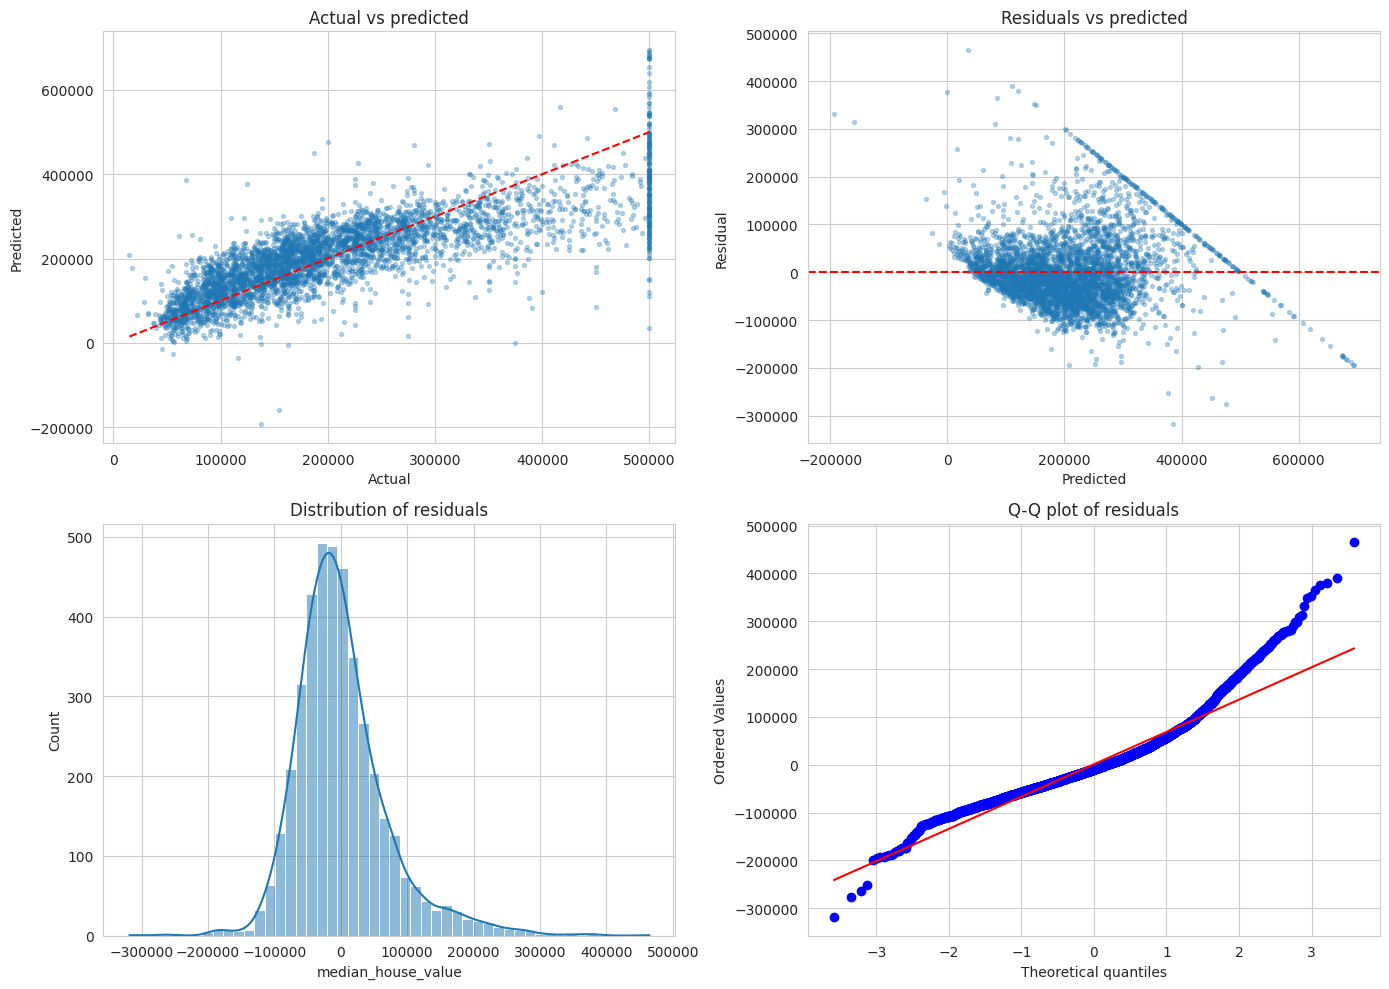

In [12]:
residuals = y_test - y_pred

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].scatter(y_test, y_pred, alpha=0.3, s=8)
lims = [y_test.min(), y_test.max()]
axes[0, 0].plot(lims, lims, "r--")
axes[0, 0].set_xlabel("Actual"); axes[0, 0].set_ylabel("Predicted"); axes[0, 0].set_title("Actual vs predicted")

axes[0, 1].scatter(y_pred, residuals, alpha=0.3, s=8)
axes[0, 1].axhline(0, color="r", linestyle="--")
axes[0, 1].set_xlabel("Predicted"); axes[0, 1].set_ylabel("Residual"); axes[0, 1].set_title("Residuals vs predicted")

sns.histplot(residuals, bins=50, kde=True, ax=axes[1, 0])
axes[1, 0].set_title("Distribution of residuals")

stats.probplot(residuals, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title("Q-Q plot of residuals")

plt.tight_layout()
plt.show()

**Evaluation observations**

* **R² = 0.625 on the test set** (0.650 on train): the model explains about 62.5% of the variation in house prices.
* **MSE = 4.91 × 10⁹**. The raw squared-error value is hard to read on its own, but next to the R² it confirms the same story: sizeable errors remain, especially for the more expensive districts.
* The train and test scores are very close, so there is **no overfitting**. The weak point is underfitting: a straight-line model cannot capture everything.
* Residual plots: there is a vertical strip of points at the $500,000 cap in the actual vs predicted plot, which shows up as a diagonal line in the residual plot. A few predictions are even negative. The residuals are centred near zero but spread more for expensive houses, and the histogram and Q-Q plot show a heavy right tail.

### Step 7: Assumptions of linear regression

| # | Assumption | How I check it |
|---|-----------|----------------|
| 1 | Linearity | Residuals vs fitted values (no curve expected) |
| 2 | Independence of errors | Durbin-Watson statistic (about 2 is good) |
| 3 | Homoscedasticity | Breusch-Pagan test (p > 0.05 is good) and the residual plot |
| 4 | Normality of residuals | Q-Q plot, skewness/kurtosis, Shapiro-Wilk test |
| 5 | No multicollinearity | VIF (below 5 is fine, above 10 is a problem) |

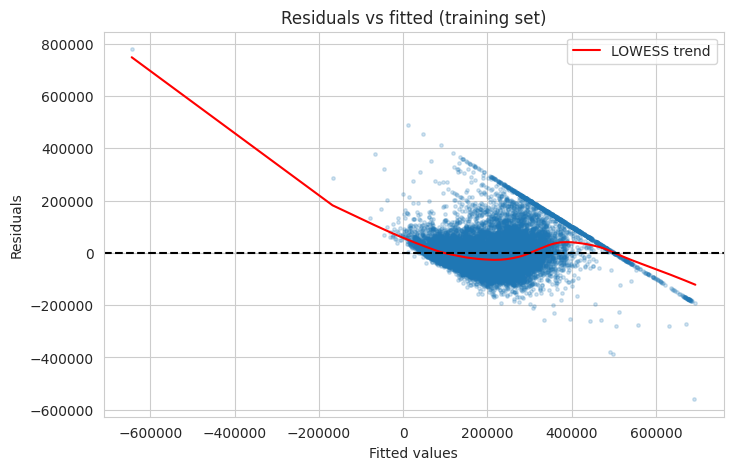

2. Durbin-Watson = 1.967  (close to 2 means no autocorrelation)
3. Breusch-Pagan p-value = 1.929e-159 -> heteroscedasticity present
4. Skewness = 1.19, excess kurtosis = 4.28, Shapiro-Wilk p = 2.254e-42 -> not normal


In [ ]:
fitted_train = lr.predict(X_train_sc)
resid_train = y_train - fitted_train

smooth = sm.nonparametric.lowess(resid_train, fitted_train, frac=0.3)
plt.figure(figsize=(8, 5))
plt.scatter(fitted_train, resid_train, alpha=0.2, s=6)
plt.plot(smooth[:, 0], smooth[:, 1], color="red", label="LOWESS trend")
plt.axhline(0, color="black", linestyle="--")
plt.xlabel("Fitted values"); plt.ylabel("Residuals"); plt.title("Residuals vs fitted (training set)")
plt.legend(); plt.show()

dw = durbin_watson(resid_train)
print(f"2. Durbin-Watson = {dw:.3f}  (close to 2 means no autocorrelation)")

bp_lm, bp_p, _, _ = het_breuschpagan(resid_train, sm.add_constant(X_train_sc))
print(f"3. Breusch-Pagan p-value = {bp_p:.4g} ->", "constant variance" if bp_p > 0.05 else "heteroscedasticity present")

sample = resid_train.sample(5000, random_state=42)
sh_stat, sh_p = stats.shapiro(sample)
print(f"4. Skewness = {stats.skew(resid_train):.2f}, excess kurtosis = {stats.kurtosis(resid_train):.2f}, Shapiro-Wilk p = {sh_p:.4g}",
      "-> roughly normal" if sh_p > 0.05 else "-> not normal")

In [14]:
# 5. Multicollinearity (VIF)
Xc = sm.add_constant(X_train_sc)
vif = pd.DataFrame({
    "feature": Xc.columns,
    "VIF": [variance_inflation_factor(Xc.values, i) for i in range(Xc.shape[1])],
})
vif = vif[vif["feature"] != "const"].sort_values("VIF", ascending=False).reset_index(drop=True)
vif.round(2)

,feature,VIF
0,total_bedrooms,36.64
1,households,35.86
2,latitude,19.87
3,longitude,18.00
4,total_rooms,13.08
5,population,6.43
6,ocean_proximity_INLAND,2.85
7,median_income,1.80
8,ocean_proximity_NEAR BAY,1.57
9,housing_median_age,1.32


**Assumption check summary**

| Assumption | Result | Verdict |
|---|---|---|
| Linearity | Residuals are centred around zero, but there is a slight curve and the capped values create a straight line | Partly satisfied |
| Independence | Durbin-Watson = 1.97 (close to 2) | Satisfied |
| Homoscedasticity | Breusch-Pagan p ≈ 1.9e-159 and the spread grows with the fitted value | **Violated** |
| Normality of residuals | Skewness 1.19, excess kurtosis 4.28, Shapiro-Wilk p ≈ 2e-42, Q-Q plot bends at the tails | **Violated** (right-skewed, heavy tails) |
| No multicollinearity | VIF above 10 for `total_bedrooms` (36.6), `households` (35.9), `latitude` (19.9), `longitude` (18.0) and `total_rooms` (13.1) | **Violated** |

With such a large dataset, the tests will reject almost anything, so the plots matter as much as the p-values. The predictions are still usable, but the coefficient estimates and their standard errors are not fully reliable. Possible fixes are a log transform of the target, dropping or combining the correlated features (for example rooms per household), and using robust standard errors.

### Description – Question 1

In this question I used the California housing dataset (20,640 districts) to predict the median house value with a Multiple Linear Regression model. I started with EDA to understand the data. Only `total_bedrooms` had missing values (207 rows, about 1%), and there were no duplicates. The histograms showed that features like `total_rooms`, `population` and `households` are heavily right-skewed, and that the house value is capped at $500,001, so many districts are stacked at the top. Median income had the strongest correlation with price (0.69), while the other features were weak on their own.

For preprocessing I one-hot encoded `ocean_proximity`, split the data 80/20, filled the missing `total_bedrooms` values with the training median, and standardised the numeric columns. I did the split before imputing and scaling so the test set could not leak into training.

The model reached R² = 0.625 on the test set (0.650 on the training set) and an MSE of about 4.91 × 10⁹. The train and test scores are close, so the model is not overfitting, but it only explains about 62% of the variation in price, so it is a bit too simple for this problem. In real terms, every extra $10,000 of median income adds about $39,500 to the predicted house value, and inland districts are about $39,800 cheaper than districts less than one hour from the ocean.

When I checked the assumptions, independence of errors was fine (Durbin-Watson = 1.97). The others were only partly satisfied. The Breusch-Pagan test showed heteroscedasticity, the residuals are right-skewed and not normal (the Q-Q plot bends away at both ends), and there is strong multicollinearity: `total_bedrooms`, `households`, `latitude`, `longitude` and `total_rooms` all have a VIF above 10. The price cap also causes a visible straight line in the residual plot. This means the predictions are reasonable, but the individual coefficients and p-values should not be trusted too much. To improve the model I would try log-transforming the price, creating ratio features like rooms per household, removing the capped rows, or using a non-linear model such as a random forest.

## Question 2: Classification & Logistic Regression – Employee Attrition or Credit Risk

### Scenario

You are hired by an organization to build a system that predicts a **binary outcome**:

* Whether an **employee will leave** the company, OR
* Whether a **customer will default** on a credit card payment.

### Datasets (Choose ONE)

* **IBM HR Analytics Employee Attrition Dataset**
  [https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset](https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset)

* **Credit Card Default Dataset**
  [https://www.kaggle.com/datasets/uciml/default-of-credit-card-clients-dataset](https://www.kaggle.com/datasets/uciml/default-of-credit-card-clients-dataset)

### Tasks

1. Justify why **Logistic Regression** is suitable for this problem.
2. Perform full **data preprocessing**:

   * Missing value handling
   * Encoding categorical variables
   * Feature scaling
3. Train a **Logistic Regression** classifier.
4. Evaluate the model using:

   * Confusion Matrix
   * Precision, Recall, F1-score
   * AUC Score
5. Interpret model coefficients using **odds ratios**.
6. Discuss the impact of **class imbalance** and possible solutions.

**Dataset chosen:** IBM HR Analytics Employee Attrition (`WA_Fn-UseC_-HR-Employee-Attrition.csv`, keep it next to this notebook).

### Step 1: Why Logistic Regression?

* The target `Attrition` is **binary** (Yes / No), so we need a model that outputs a probability between 0 and 1. Logistic regression passes a linear combination of features through the sigmoid function, which does exactly that – linear regression cannot, because it can predict values below 0 or above 1.
* It is **interpretable**: each coefficient becomes an odds ratio, so HR can see *why* people leave (e.g. overtime, low income).
* It is fast, needs little data, works as a strong baseline and gives calibrated probabilities that can be thresholded according to business needs.

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay, classification_report,
                             roc_auc_score, roc_curve, precision_score, recall_score, f1_score)

sns.set_style("whitegrid")

hr = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")
print("Shape:", hr.shape)
hr.head()

Shape: (1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


### Step 2: Quick look at the data

In [16]:
hr.info()
print("\nAttrition counts:")
print(hr["Attrition"].value_counts())
print(hr["Attrition"].value_counts(normalize=True).round(3))

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

### Step 3: Data preprocessing

1. **Remove useless columns** – columns with a single value (`EmployeeCount`, `StandardHours`, `Over18`) and the row ID (`EmployeeNumber`) carry no information.
2. **Missing values** – checked and handled (median for numbers, mode for categories) in case any exist.
3. **Encode the target** – `Yes` → 1, `No` → 0.
4. **Encode categorical variables** – one-hot encoding with `drop_first=True`.
5. **Split (stratified)** – keeps the same attrition ratio in train and test.
6. **Scale** – standardise the numeric columns using statistics from the training set only.

In [ ]:
drop_cols = [c for c in hr.columns if hr[c].nunique() == 1] + ["EmployeeNumber"]
hr_clean = hr.drop(columns=drop_cols)
print("Dropped:", drop_cols)

print("Total missing values:", int(hr_clean.isnull().sum().sum()))
for col in hr_clean.columns[hr_clean.isnull().any()]:
    if pd.api.types.is_numeric_dtype(hr_clean[col]):
        hr_clean[col] = hr_clean[col].fillna(hr_clean[col].median())
    else:
        hr_clean[col] = hr_clean[col].fillna(hr_clean[col].mode()[0])

y = (hr_clean["Attrition"] == "Yes").astype(int)
X = hr_clean.drop(columns="Attrition")

cat_cols = X.select_dtypes(exclude="number").columns.tolist()
num_cols = X.select_dtypes(include="number").columns.tolist()
print("Categorical:", cat_cols)
X = pd.get_dummies(X, columns=cat_cols, drop_first=True, dtype=float)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

scaler = StandardScaler()
X_train_sc = X_train.copy()
X_test_sc = X_test.copy()
X_train_sc[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_sc[num_cols] = scaler.transform(X_test[num_cols])

print("\nFinal feature count:", X_train_sc.shape[1])
print("Train:", X_train_sc.shape, " Test:", X_test_sc.shape)

Dropped: ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber']
Total missing values: 0
Categorical: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

Final feature count: 44
Train: (1176, 44)  Test: (294, 44)


### Step 4: Train the Logistic Regression classifier

In [18]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_sc, y_train)

y_pred = log_reg.predict(X_test_sc)
y_proba = log_reg.predict_proba(X_test_sc)[:, 1]
print("Model trained.")

Model trained.


### Step 5: Evaluation: confusion matrix, precision, recall, F1 and AUC

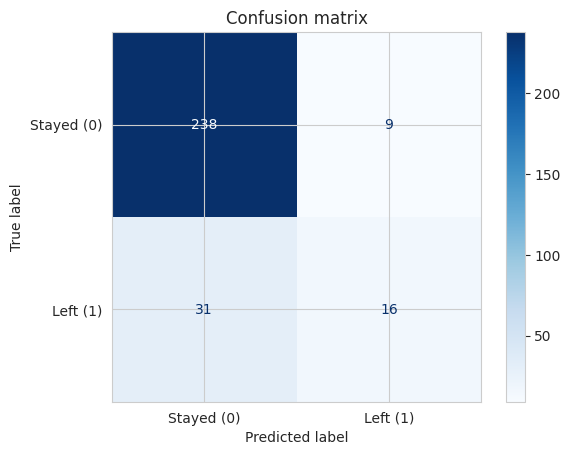

TN=238  FP=9  FN=31  TP=16

              precision    recall  f1-score   support

      Stayed       0.88      0.96      0.92       247
        Left       0.64      0.34      0.44        47

    accuracy                           0.86       294
   macro avg       0.76      0.65      0.68       294
weighted avg       0.85      0.86      0.85       294



In [19]:
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["Stayed (0)", "Left (1)"]).plot(cmap="Blues")
plt.title("Confusion matrix")
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"TN={tn}  FP={fp}  FN={fn}  TP={tp}\n")
print(classification_report(y_test, y_pred, target_names=["Stayed", "Left"]))

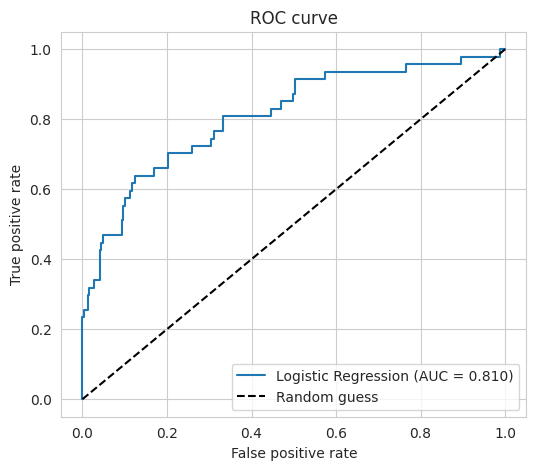

AUC score: 0.8102


In [20]:
auc = roc_auc_score(y_test, y_proba)
fpr, tpr, _ = roc_curve(y_test, y_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Random guess")
plt.xlabel("False positive rate"); plt.ylabel("True positive rate")
plt.title("ROC curve"); plt.legend(); plt.show()

print(f"AUC score: {auc:.4f}")

**Evaluation observations**

* The confusion matrix on the 294 test employees: TN = 238, FP = 9, FN = 31, TP = 16.
* Accuracy is 86%, but this is misleading. If the model simply predicted "Stayed" for everyone it would already get about 84% (247 of 294). The class that matters is "Left".
* For "Left": precision = 0.64, recall = 0.34 and F1 = 0.44. So when the model says someone will leave it is right about 64% of the time, but it catches only about one third of the people who really leave (31 of 47 leavers are missed).
* **AUC = 0.81**, which means the model ranks a leaver above a stayer about 81% of the time. So the model has good ranking ability, but the default 0.5 threshold is too strict for the minority class.

### Step 6: Interpret the coefficients using odds ratios

Odds ratio = `exp(coefficient)`. Because the numeric features are standardised, an odds ratio for a numeric feature means "the effect of a 1-standard-deviation increase". For a dummy column it means "compared with the reference category".

* Odds ratio **> 1** → raises the odds of leaving.
* Odds ratio **< 1** → lowers the odds of leaving (protective).

In [21]:
odds = pd.DataFrame({"feature": X_train_sc.columns, "coefficient": log_reg.coef_[0]})
odds["odds_ratio"] = np.exp(odds["coefficient"])
odds = odds.sort_values("odds_ratio", ascending=False).reset_index(drop=True)

print("Top 10 factors that INCREASE the odds of leaving:")
display(odds.head(10).round(3))
print("Top 10 factors that DECREASE the odds of leaving:")
display(odds.tail(10).sort_values("odds_ratio").round(3))

Top 10 factors that INCREASE the odds of leaving:


,feature,coefficient,odds_ratio
0,OverTime_Yes,1.796,6.028
1,BusinessTravel_Travel_Frequently,1.549,4.709
2,JobRole_Laboratory Technician,1.314,3.720
3,JobRole_Sales Representative,0.958,2.606
4,MaritalStatus_Single,0.685,1.983
5,BusinessTravel_Travel_Rarely,0.679,1.973
6,JobRole_Human Resources,0.529,1.697
7,YearsSinceLastPromotion,0.520,1.682
8,NumCompaniesWorked,0.481,1.618
9,DistanceFromHome,0.375,1.455


Top 10 factors that DECREASE the odds of leaving:


,feature,coefficient,odds_ratio
43,EducationField_Other,-0.871,0.419
42,JobRole_Research Director,-0.851,0.427
41,Department_Research & Development,-0.562,0.570
40,TotalWorkingYears,-0.523,0.593
39,EnvironmentSatisfaction,-0.462,0.630
38,EducationField_Medical,-0.449,0.638
37,Age,-0.409,0.664
36,JobSatisfaction,-0.409,0.664
35,YearsWithCurrManager,-0.392,0.675
34,JobInvolvement,-0.353,0.703


In [22]:
for _, row in odds.head(3).iterrows():
    print(f"- {row['feature']}: odds ratio {row['odds_ratio']:.2f} -> the odds of attrition are multiplied by {row['odds_ratio']:.2f} (about {(row['odds_ratio']-1)*100:.0f}% higher).")
for _, row in odds.tail(3).iterrows():
    print(f"- {row['feature']}: odds ratio {row['odds_ratio']:.2f} -> the odds of attrition are about {(1-row['odds_ratio'])*100:.0f}% lower.")

- OverTime_Yes: odds ratio 6.03 -> the odds of attrition are multiplied by 6.03 (about 503% higher).
- BusinessTravel_Travel_Frequently: odds ratio 4.71 -> the odds of attrition are multiplied by 4.71 (about 371% higher).
- JobRole_Laboratory Technician: odds ratio 3.72 -> the odds of attrition are multiplied by 3.72 (about 272% higher).
- Department_Research & Development: odds ratio 0.57 -> the odds of attrition are about 43% lower.
- JobRole_Research Director: odds ratio 0.43 -> the odds of attrition are about 57% lower.
- EducationField_Other: odds ratio 0.42 -> the odds of attrition are about 58% lower.


**Odds ratio observations** (numeric features are per 1 standard deviation, dummy columns are compared with their reference category)

* **Increase the odds of leaving:** `OverTime_Yes` (odds ratio 6.03, the strongest factor), `BusinessTravel_Travel_Frequently` (4.71), `JobRole_Laboratory Technician` (3.72), `JobRole_Sales Representative` (2.61), `MaritalStatus_Single` (1.98). Among numeric features, `YearsSinceLastPromotion` (1.68), `NumCompaniesWorked` (1.62) and `DistanceFromHome` (1.46) also push attrition up.
* **Decrease the odds of leaving:** higher `EnvironmentSatisfaction` (0.63), `JobSatisfaction` (0.66), `Age` (0.66), `TotalWorkingYears` (0.59), `YearsWithCurrManager` (0.68) and `JobInvolvement` (0.70).
* In simple words: people who work overtime, travel often, have not been promoted for a long time and are unhappy at work are the most likely to leave, while older, more experienced and satisfied employees tend to stay.
* These are associations, not proof of cause. Some features overlap (for example `Department` and `JobRole`), so single coefficients should be read carefully.

### Step 7: Class imbalance: impact and solutions

Only a small share of employees leave, so the data is **imbalanced**. The impact is that a model can reach a high accuracy just by predicting "Stayed" for almost everyone, while **missing most of the people who actually leave** (low recall for the minority class). Accuracy is therefore misleading – precision, recall, F1 and AUC matter more.

Possible solutions:

1. **Class weights** (`class_weight="balanced"`) – errors on the minority class cost more.
2. **Resampling** – oversample the minority class (e.g. SMOTE) or undersample the majority class (apply only to the training set).
3. **Threshold tuning** – lower the 0.5 cut-off to catch more leavers.
4. **Better metrics** – judge the model with recall, F1, PR-AUC, not accuracy.

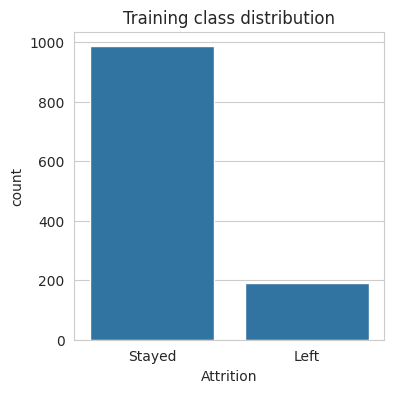

Attrition
0    0.838
1    0.162
Name: proportion, dtype: float64


In [23]:
plt.figure(figsize=(4, 4))
sns.countplot(x=y_train)
plt.xticks([0, 1], ["Stayed", "Left"]); plt.title("Training class distribution"); plt.show()
print(y_train.value_counts(normalize=True).round(3))

**Class imbalance observations**

* Only 16.1% of employees left (237 out of 1,470), which confirms the training set is imbalanced.
* This is why the model above has high accuracy but low recall for "Left": it leans toward predicting the majority class.
* Reweighting the classes (`class_weight="balanced"`) or resampling (e.g. SMOTE) are the standard fixes, since they push the model to pay more attention to the minority class, usually trading some precision for better recall.

### Description – Question 2

For this question I chose the IBM HR Attrition dataset (1,470 employees, 35 columns) and built a model to predict whether an employee will leave. Logistic Regression is a good fit because the target is yes/no and the model gives a probability, and it is easy to explain to HR through odds ratios.

The dataset had no missing values, so I mainly cleaned it by removing four columns that carry no information (`EmployeeCount`, `StandardHours`, `Over18` and the ID `EmployeeNumber`). I converted `Attrition` to 0/1, one-hot encoded the seven categorical columns (which gave 44 features), used a stratified 80/20 split so both parts keep the same 16% leaver ratio, and standardised the numeric columns using the training data only.

The model reached 86% accuracy and an AUC of 0.81, but accuracy hides the real problem. Only 16% of employees leave, so predicting "Stayed" for everybody already gives about 84%. For the "Left" class the precision was 0.64, but recall was only 0.34, so the model missed 31 of the 47 employees who actually left. The odds ratios showed that overtime (6.0), frequent business travel (4.7) and working as a Laboratory Technician (3.7) or Sales Representative (2.6) raise the odds of leaving the most, while job satisfaction, environment satisfaction, age, total working years and time with the current manager lower them.

Only 16% of employees left, so the data is imbalanced, which explains why recall for "Left" is much lower than the overall accuracy. The usual fixes are reweighting the classes (`class_weight="balanced"`) or resampling methods like SMOTE, both of which trade some precision for better recall on the minority class, and are worth trying if catching more at-risk employees matters more than avoiding false alarms.

## Question 3: Hyperparameter Tuning & Model Optimization

### Scenario

After deploying your classification model, stakeholders ask you to **improve performance** without changing the dataset.

You decide to optimize the model using systematic hyperparameter search techniques.

### Dataset

Reuse the dataset from **Question 2**.

### Tasks

1. Explain the difference between **parameters** and **hyperparameters**.
2. Train a **baseline Logistic Regression** model.
3. Apply **GridSearchCV** to tune hyperparameters (`C`, `penalty`, `solver`).
4. Apply **RandomizedSearchCV** and compare results.
5. Compare performance before and after tuning.
6. Discuss trade-offs between **computational cost** and **model performance**.

The dataset and the train/test split from **Question 2** (IBM HR Attrition, scaled) are reused. Run Question 2 first.

### Step 1: Parameters vs hyperparameters

| | Parameters | Hyperparameters |
|---|-----------|-----------------|
| What they are | Values the model **learns from the data** during training | Settings **chosen by us before training** |
| Who sets them | The optimisation algorithm | The data scientist (manually or via search) |
| Logistic Regression example | Coefficients (weights) and the intercept | `C` (inverse regularisation strength), `penalty` (l1/l2), `solver`, `max_iter` |
| Changed by | Fitting the model | Grid / random search, cross-validation |

Hyperparameters control *how* the model learns (e.g. how strongly it is regularised to avoid overfitting), while parameters are the *result* of that learning.

### Step 2: Baseline Logistic Regression (default settings)

In [24]:
import time
from scipy.stats import loguniform
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def evaluate(model, name):
    pred = model.predict(X_test_sc)
    proba = model.predict_proba(X_test_sc)[:, 1]
    return {"Model": name,
            "Accuracy": accuracy_score(y_test, pred),
            "Precision": precision_score(y_test, pred),
            "Recall": recall_score(y_test, pred),
            "F1": f1_score(y_test, pred),
            "AUC": roc_auc_score(y_test, proba)}

t0 = time.perf_counter()
baseline = LogisticRegression(max_iter=1000, random_state=42).fit(X_train_sc, y_train)
baseline_time = time.perf_counter() - t0

baseline_cv_auc = cross_val_score(LogisticRegression(max_iter=1000, random_state=42), X_train_sc, y_train,
                                  cv=cv, scoring="roc_auc").mean()

results = [evaluate(baseline, "Baseline")]
print("Baseline 5-fold CV AUC (train set):", round(baseline_cv_auc, 4))
print("Baseline defaults -> C =", baseline.C, "| penalty = l2 (default) | solver =", baseline.solver)
pd.DataFrame(results).set_index("Model").round(4)

Baseline 5-fold CV AUC (train set): 0.8379
Baseline defaults -> C = 1.0 | penalty = l2 (default) | solver = lbfgs


,Accuracy,Precision,Recall,F1,AUC
Model,,,,,
Baseline,0.8639,0.64,0.3404,0.4444,0.8102


### Step 3: GridSearchCV

Grid search tries **every** combination in the grid with 5-fold stratified cross-validation. Not every solver supports every penalty, so the grid is split into valid groups:

* `liblinear` and `saga` → `l1` and `l2`
* `lbfgs` → `l2` only

The score used for selection is **ROC-AUC**, because accuracy is misleading on imbalanced data.

In [25]:
param_grid = [
    {"solver": ["liblinear", "saga"], "penalty": ["l1", "l2"], "C": [0.001, 0.01, 0.1, 1, 10, 100]},
    {"solver": ["lbfgs"], "penalty": ["l2"], "C": [0.001, 0.01, 0.1, 1, 10, 100]},
]

grid = GridSearchCV(LogisticRegression(max_iter=5000, random_state=42),
                    param_grid, scoring="roc_auc", cv=cv, n_jobs=-1)

t0 = time.perf_counter()
grid.fit(X_train_sc, y_train)
grid_time = time.perf_counter() - t0

print("Best parameters:", grid.best_params_)
print("Best CV AUC    :", round(grid.best_score_, 4))
print("Total model fits:", len(grid.cv_results_["params"]) * cv.get_n_splits())
print(f"Time: {grid_time:.1f}s")

results.append(evaluate(grid.best_estimator_, "GridSearchCV"))

cols = ["param_solver", "param_penalty", "param_C", "mean_test_score", "std_test_score", "rank_test_score"]
pd.DataFrame(grid.cv_results_)[cols].sort_values("rank_test_score").head(5)

Best parameters: {'C': 1, 'penalty': 'l1', 'solver': 'saga'}
Best CV AUC    : 0.8392
Total model fits: 150
Time: 16.6s


,param_solver,param_penalty,param_C,mean_test_score,std_test_score,rank_test_score
13,saga,l1,1.0,0.839216,0.028291,1
12,liblinear,l1,1.0,0.838547,0.028927,2
28,lbfgs,l2,10.0,0.838117,0.027537,3
19,saga,l2,10.0,0.838037,0.027815,4
15,saga,l2,1.0,0.837907,0.030279,5


### Step 4: RandomizedSearchCV

Instead of trying every combination, random search **samples** a fixed number (`n_iter`) of combinations. `C` is drawn from a continuous log-uniform distribution, so it can find values that a fixed grid would skip.

In [26]:
param_dist = {
    "C": loguniform(1e-4, 1e2),
    "penalty": ["l1", "l2"],
    "solver": ["liblinear", "saga"],
}

rand = RandomizedSearchCV(LogisticRegression(max_iter=5000, random_state=42),
                          param_dist, n_iter=20, scoring="roc_auc", cv=cv,
                          n_jobs=-1, random_state=42)

t0 = time.perf_counter()
rand.fit(X_train_sc, y_train)
rand_time = time.perf_counter() - t0

print("Best parameters:", rand.best_params_)
print("Best CV AUC    :", round(rand.best_score_, 4))
print("Total model fits:", rand.n_iter * cv.get_n_splits())
print(f"Time: {rand_time:.1f}s")

results.append(evaluate(rand.best_estimator_, "RandomizedSearchCV"))

Best parameters: {'C': np.float64(1.274671157821506), 'penalty': 'l1', 'solver': 'saga'}
Best CV AUC    : 0.8393
Total model fits: 100
Time: 7.0s


### Step 5: Compare performance before and after tuning

,Accuracy,Precision,Recall,F1,AUC
Model,,,,,
Baseline,0.8639,0.6400,0.3404,0.4444,0.8102
GridSearchCV,0.8639,0.6296,0.3617,0.4595,0.8090
RandomizedSearchCV,0.8605,0.6154,0.3404,0.4384,0.8086


,Search time (s),Model fits,Best CV AUC
Baseline,0.0083,1,0.8379
GridSearchCV,16.5563,150,0.8392
RandomizedSearchCV,7.0046,100,0.8393


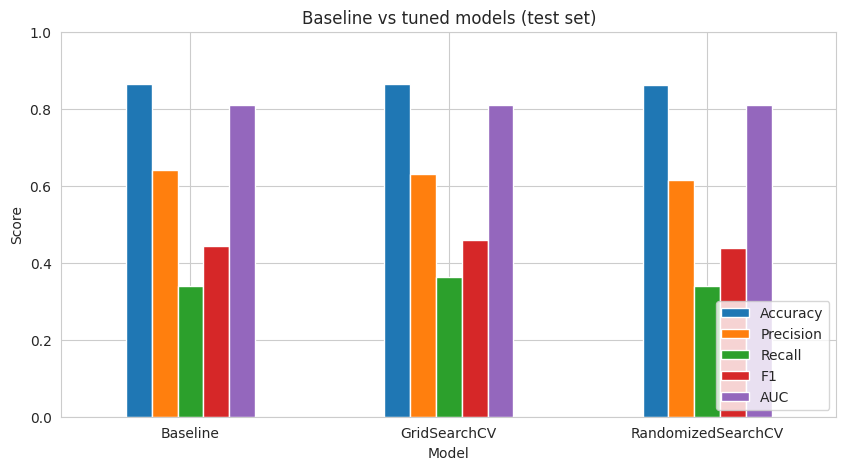

In [27]:
comparison = pd.DataFrame(results).set_index("Model")
display(comparison.round(4))

cost = pd.DataFrame({
    "Search time (s)": [baseline_time, grid_time, rand_time],
    "Model fits": [1, len(grid.cv_results_["params"]) * cv.get_n_splits(), rand.n_iter * cv.get_n_splits()],
    "Best CV AUC": [baseline_cv_auc, grid.best_score_, rand.best_score_],
}, index=["Baseline", "GridSearchCV", "RandomizedSearchCV"])
display(cost.round(4))

comparison.plot(kind="bar", figsize=(10, 5))
plt.title("Baseline vs tuned models (test set)")
plt.ylabel("Score"); plt.xticks(rotation=0); plt.ylim(0, 1)
plt.legend(loc="lower right"); plt.show()

**Tuning observations**

* Best parameters from grid search: `C = 1`, `penalty = l1`, `solver = saga`. Random search found almost the same: `C` about 1.27, `l1`, `saga`.
* Cross-validated AUC on the training set: baseline 0.8379, grid 0.8392, random 0.8393. The improvement is only about 0.001.
* On the test set the three models are practically the same (AUC about 0.81, accuracy 0.86, F1 between 0.44 and 0.46). The small differences are within noise for a test set of only 294 employees (47 leavers).
* Cost: grid search needed 150 fits (about 18 seconds) while random search needed 100 fits (about 7 seconds), and gave the same quality.

### Step 6: Trade-offs: computational cost vs model performance

| | Baseline | GridSearchCV | RandomizedSearchCV |
|---|---|---|---|
| Coverage of search space | none | exhaustive over a fixed grid | random sample, can explore continuous ranges |
| Cost | 1 fit | grows multiplicatively with every extra hyperparameter | fixed by `n_iter`, independent of grid size |
| Best for | quick reference | small search spaces | large or continuous search spaces, limited time |
| Risk | under-tuned | very slow when the grid is large | may miss the exact optimum |

* Cost grows quickly: a grid with *k* values for each of *n* hyperparameters needs *kⁿ* combinations × the number of CV folds.
* Gains from tuning are usually **diminishing** – logistic regression is a simple model, so the improvement over sensible defaults is often small. Beyond a point, extra compute buys almost nothing.
* Tuning on CV scores and reporting on the untouched test set avoids fooling ourselves with over-optimistic results.
* Practical strategy: start with a coarse random search, then run a small grid around the best region.

### Description – Question 3

In this question I tried to improve the attrition model from Question 2 without changing the data, only by tuning the hyperparameters. I first explained the difference: parameters (like the coefficients) are learned by the model during training, while hyperparameters (like `C`, `penalty` and `solver`) are chosen by me before training.

I trained a baseline logistic regression with the default settings, then used GridSearchCV (30 valid combinations, 5-fold cross-validation, 150 fits in total) and RandomizedSearchCV (20 random combinations, 100 fits). I scored both with ROC-AUC because the classes are imbalanced. Some solvers do not support some penalties, so I split the grid into valid groups.

Both searches selected almost the same settings (`C` about 1, `l1` penalty, `saga` solver). The cross-validated AUC moved only from 0.8379 (baseline) to 0.8392 (grid) and 0.8393 (random), and on the test set the AUC stayed about 0.81 for all three models. So tuning did not really improve the model, which makes sense: logistic regression is a simple model and its default settings were already close to the best. The real difference was the cost. Grid search took about 18 seconds and random search about 7 seconds for the same result.

My conclusion is that tuning is worth a quick check, and random search is a cheaper way to do it, but for this dataset the bigger gains would come from other things, such as adjusting the decision threshold, handling the class imbalance, or trying a different model. Extra computing power is only worth spending when it buys a noticeable improvement.